In [1]:
import pandas as pd
import seaborn as sns
df = pd.read_csv(r"..\..\dataset\dataset_module_one_DM2.csv")

In [2]:
df = df[df['CGAS-CGAS_Score'] < 100]

## Regressione CGAS-CGAS_Score

Fitting RFECV for Random Forest...
Fitting RFECV for XGBoost...

Optimal features (Random Forest): 35
Optimal features (XGBoost): 36


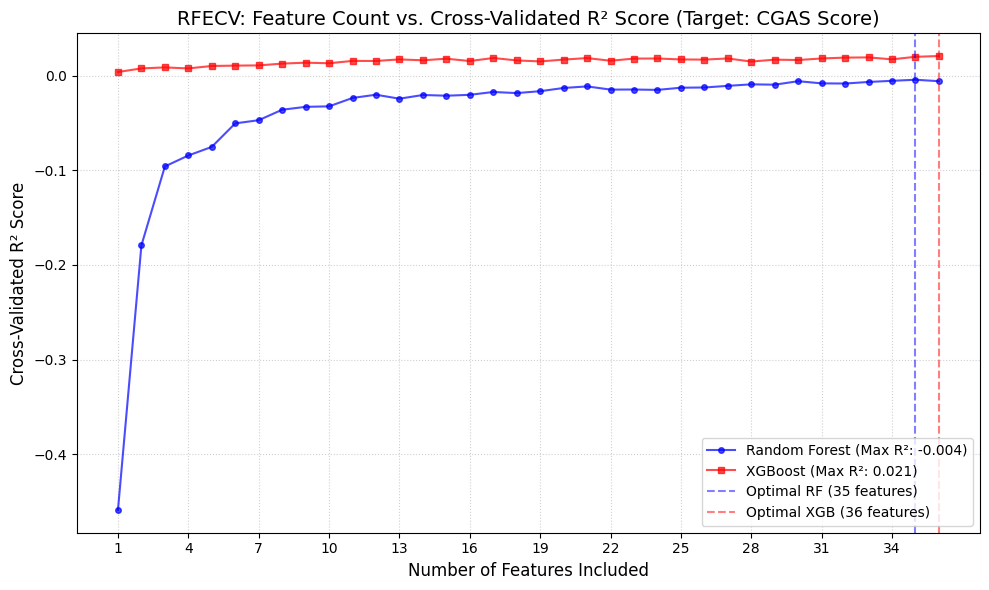


--- Final Evaluation on Unseen Test Set (Optimal Features) ---
Random Forest -> MSE: 71.1797 | R²: -0.0156
XGBoost       -> MSE: 69.7858 | R²: 0.0043

Selected Features by Random Forest: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL_Zone', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Body_Mass_Index_Global', 'Body_Proportion', 'Fitness_Endurance-Time', 'Mean_Arterial_Pressure']
Selected Features by XGBoost: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_CU_

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# Block 1: Data Setup & Target Definition
# ==========================================

target = 'CGAS-CGAS_Score'

# For predicting psychological well-being (CGAS), physical/fitness features 
# do not cause mathematical data leakage. We only need to drop the target itself.
X = df.copy()

if target in X.columns:
    X = X.drop(columns=[target])

y = df[target]

# Drop rows where the target is NaN
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# Block 2: Models & RFECV Setup
# ==========================================

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Highly regularized XGBoost to handle noise, outliers, and prevent overfitting
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    reg_lambda=1.5, 
    random_state=42, 
    n_jobs=-1
)

cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

# Using step=1 to strictly map 1 evaluation to 1 feature on the X-axis
rfecv_rf = RFECV(estimator=rf_model, step=1, cv=cv_strategy, scoring='r2', min_features_to_select=1, n_jobs=-1)
rfecv_xgb = RFECV(estimator=xgb_model, step=1, cv=cv_strategy, scoring='r2', min_features_to_select=1, n_jobs=-1)

# ==========================================
# Block 3: Model Fitting
# ==========================================

print("Fitting RFECV for Random Forest...")
rfecv_rf.fit(X_train, y_train)

print("Fitting RFECV for XGBoost...")
rfecv_xgb.fit(X_train, y_train)

optimal_features_rf = rfecv_rf.n_features_
optimal_features_xgb = rfecv_xgb.n_features_

print(f"\nOptimal features (Random Forest): {optimal_features_rf}")
print(f"Optimal features (XGBoost): {optimal_features_xgb}")

# ==========================================
# Block 4: Extracting Results & Plotting
# ==========================================

scores_rf = rfecv_rf.cv_results_['mean_test_score']
scores_xgb = rfecv_xgb.cv_results_['mean_test_score']

num_features_evaluated = len(scores_rf)
x_axis = range(1, num_features_evaluated + 1)

plt.figure(figsize=(10, 6))

plt.plot(x_axis, scores_rf, label=f'Random Forest (Max R²: {max(scores_rf):.3f})', 
         color='blue', marker='o', markersize=4, alpha=0.7)
plt.plot(x_axis, scores_xgb, label=f'XGBoost (Max R²: {max(scores_xgb):.3f})', 
         color='red', marker='s', markersize=4, alpha=0.7)

plt.axvline(x=optimal_features_rf, color='blue', linestyle='--', alpha=0.5, 
            label=f'Optimal RF ({optimal_features_rf} features)')
plt.axvline(x=optimal_features_xgb, color='red', linestyle='--', alpha=0.5, 
            label=f'Optimal XGB ({optimal_features_xgb} features)')

plt.title('RFECV: Feature Count vs. Cross-Validated R² Score (Target: CGAS Score)', fontsize=14)
plt.xlabel('Number of Features Included', fontsize=12)
plt.ylabel('Cross-Validated R² Score', fontsize=12)

plt.xticks(range(1, num_features_evaluated + 1, max(1, num_features_evaluated // 10)))

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

# ==========================================
# Block 5: Final Evaluation on Unseen Data
# ==========================================

preds_rf_opt = rfecv_rf.predict(X_test)
preds_xgb_opt = rfecv_xgb.predict(X_test)

print("\n--- Final Evaluation on Unseen Test Set (Optimal Features) ---")
print(f"Random Forest -> MSE: {mean_squared_error(y_test, preds_rf_opt):.4f} | R²: {r2_score(y_test, preds_rf_opt):.4f}")
print(f"XGBoost       -> MSE: {mean_squared_error(y_test, preds_xgb_opt):.4f} | R²: {r2_score(y_test, preds_xgb_opt):.4f}")

# Extract and print the names of the selected features for BOTH models
selected_features_rf = X.columns[rfecv_rf.support_]
print(f"\nSelected Features by Random Forest: {list(selected_features_rf)}")

selected_features_xgb = X.columns[rfecv_xgb.support_]
print(f"Selected Features by XGBoost: {list(selected_features_xgb)}")

## Regressione su BIA-BIA_BMI

Fitting RFECV for Random Forest...
Fitting RFECV for XGBoost...

Optimal features (Random Forest): 17
Optimal features (XGBoost): 7


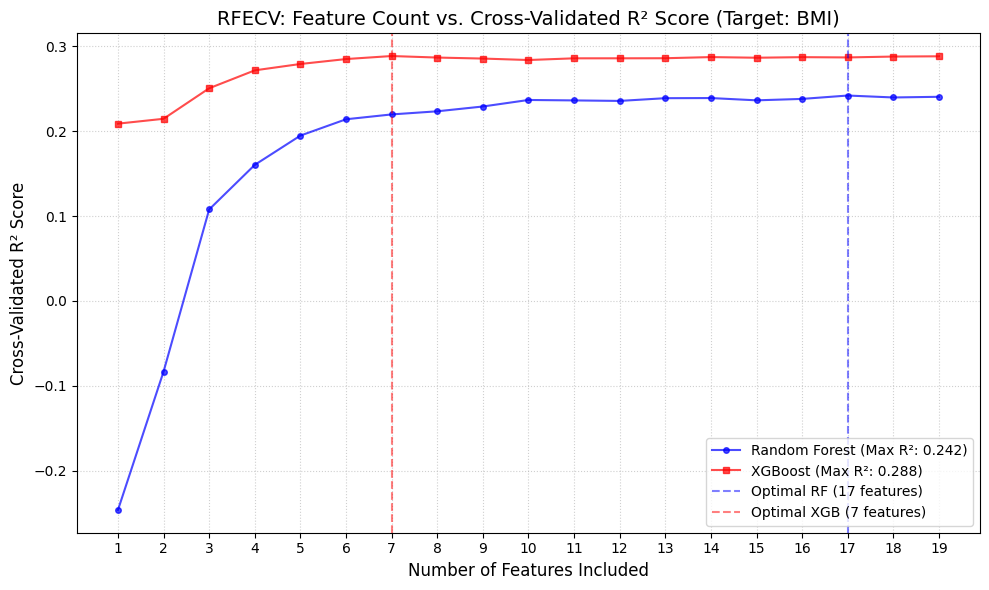


--- Final Evaluation on Unseen Test Set (Optimal Features) ---
Random Forest -> MSE: 7.2843 | R²: 0.2454
XGBoost       -> MSE: 6.8088 | R²: 0.2947

Selected Features by Random Forest: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRR_Zone', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Fitness_Endurance-Time', 'Mean_Arterial_Pressure']

Selected Features by XGBoost: ['Basic_Demos-Age', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_CU_Zone', 'FGC-FGC_PU_Zone', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time', 'Mean_Arterial_Pressure']


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# Block 1: Data Setup & Anti-Leakage (CORRECTED)
# ==========================================

target = 'BIA-BIA_BMI'

# Silo 1 features (Data Leakage for BMI prediction)
leaky_features = [
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 
    'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 
    'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 
    'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 
    'Body_Mass_Index_Global', 'Body_Proportion'
]

features_to_drop = [col for col in leaky_features if col in df.columns]

# Drop leaky features
X = df.drop(columns=features_to_drop)

# CRITICAL FIX: Explicitly drop the target variable from X!
if target in X.columns:
    X = X.drop(columns=[target])

y = df[target]

# Drop NaNs based on target
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# Block 2: Models & RFECV Setup
# ==========================================

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    reg_lambda=1.5, 
    random_state=42, 
    n_jobs=-1
)

cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

# Using step=1 to ensure the plot strictly maps 1 evaluation to 1 feature
rfecv_rf = RFECV(estimator=rf_model, step=1, cv=cv_strategy, scoring='r2', min_features_to_select=1, n_jobs=-1)
rfecv_xgb = RFECV(estimator=xgb_model, step=1, cv=cv_strategy, scoring='r2', min_features_to_select=1, n_jobs=-1)

# ==========================================
# Block 3: Model Fitting
# ==========================================

print("Fitting RFECV for Random Forest...")
rfecv_rf.fit(X_train, y_train)

print("Fitting RFECV for XGBoost...")
rfecv_xgb.fit(X_train, y_train)

optimal_features_rf = rfecv_rf.n_features_
optimal_features_xgb = rfecv_xgb.n_features_

print(f"\nOptimal features (Random Forest): {optimal_features_rf}")
print(f"Optimal features (XGBoost): {optimal_features_xgb}")

# ==========================================
# Block 4: Extracting Results & Plotting
# ==========================================

scores_rf = rfecv_rf.cv_results_['mean_test_score']
scores_xgb = rfecv_xgb.cv_results_['mean_test_score']

# Create the X-axis (Number of Features)
num_features_evaluated = len(scores_rf)
x_axis = range(1, num_features_evaluated + 1)

# Plotting the Performance Curve to visually inspect the "elbow"
plt.figure(figsize=(10, 6))

plt.plot(x_axis, scores_rf, label=f'Random Forest (Max R²: {max(scores_rf):.3f})', 
         color='blue', marker='o', markersize=4, alpha=0.7)
plt.plot(x_axis, scores_xgb, label=f'XGBoost (Max R²: {max(scores_xgb):.3f})', 
         color='red', marker='s', markersize=4, alpha=0.7)

# Highlight the optimal points (the "peaks" automatically selected by RFECV)
plt.axvline(x=optimal_features_rf, color='blue', linestyle='--', alpha=0.5, 
            label=f'Optimal RF ({optimal_features_rf} features)')
plt.axvline(x=optimal_features_xgb, color='red', linestyle='--', alpha=0.5, 
            label=f'Optimal XGB ({optimal_features_xgb} features)')

plt.title('RFECV: Feature Count vs. Cross-Validated R² Score (Target: BMI)', fontsize=14)
plt.xlabel('Number of Features Included', fontsize=12)
plt.ylabel('Cross-Validated R² Score', fontsize=12)

# Dynamic tick spacing to avoid overlapping numbers on X-axis
plt.xticks(range(1, num_features_evaluated + 1, max(1, num_features_evaluated // 10)))

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

# Display the curve
plt.show()

# ==========================================
# Block 5: Final Evaluation on Unseen Data
# ==========================================

preds_rf_opt = rfecv_rf.predict(X_test)
preds_xgb_opt = rfecv_xgb.predict(X_test)

print("\n--- Final Evaluation on Unseen Test Set (Optimal Features) ---")
print(f"Random Forest -> MSE: {mean_squared_error(y_test, preds_rf_opt):.4f} | R²: {r2_score(y_test, preds_rf_opt):.4f}")
print(f"XGBoost       -> MSE: {mean_squared_error(y_test, preds_xgb_opt):.4f} | R²: {r2_score(y_test, preds_xgb_opt):.4f}")

selected_features_rf = X.columns[rfecv_rf.support_]
print(f"\nSelected Features by Random Forest: {list(selected_features_rf)}")

# Print the names of the selected features for XGBoost (usually the best performer here)
selected_features_xgb = X.columns[rfecv_xgb.support_]
print(f"\nSelected Features by XGBoost: {list(selected_features_xgb)}")

## Regressione Fitness_Endurance-Max_Stage

Fitting RFECV for Random Forest...
Fitting RFECV for XGBoost...

Optimal features (Random Forest): 19
Optimal features (XGBoost): 33


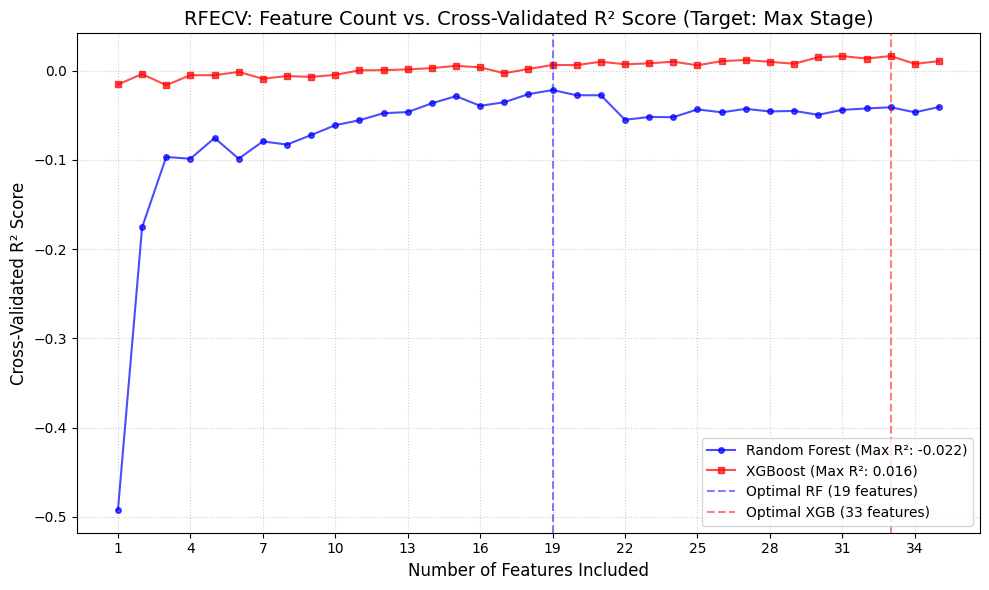


--- Final Evaluation on Unseen Test Set (Optimal Features) ---
Random Forest -> MSE: 1.1038 | R²: 0.0082
XGBoost       -> MSE: 1.0888 | R²: 0.0217

Selected Features by Random Forest: ['CGAS-CGAS_Score', 'Physical-HeartRate', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total', 'SDS-SDS_Total_T', 'Body_Mass_Index_Global', 'Body_Proportion', 'Mean_Arterial_Pressure']

Selected Features by XGBoost: ['Basic_Demos-Age', 'CGAS-CGAS_Score', 'Physical-HeartRate', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL_Zone', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PA

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# Block 1: Data Setup & Anti-Leakage
# ==========================================

target = 'Fitness_Endurance-Max_Stage'

# Silo 2 features (Data Leakage per l'Endurance)
# Chi sta più tempo sul test raggiunge matematicamente lo stage più alto. 
# Usare il 'Time' per prevedere il 'Max_Stage' creerebbe un R2 perfetto ma falso.
leaky_features = ['Fitness_Endurance-Time']

features_to_drop = [col for col in leaky_features if col in df.columns]

# Separazione target e rimozione esplicita delle variabili leaky
X = df.drop(columns=features_to_drop)
if target in X.columns:
    X = X.drop(columns=[target])
    
y = df[target]

# Rimozione dei valori nulli per evitare crash
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# Block 2: Models & RFECV Setup
# ==========================================

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# XGBoost regolarizzato per dataset complessi
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    reg_lambda=1.5, 
    random_state=42, 
    n_jobs=-1
)

cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

# step=1 assicura che l'asse X del grafico mostri esattamente il numero di feature
rfecv_rf = RFECV(estimator=rf_model, step=1, cv=cv_strategy, scoring='r2', min_features_to_select=1, n_jobs=-1)
rfecv_xgb = RFECV(estimator=xgb_model, step=1, cv=cv_strategy, scoring='r2', min_features_to_select=1, n_jobs=-1)

# ==========================================
# Block 3: Model Fitting
# ==========================================

print("Fitting RFECV for Random Forest...")
rfecv_rf.fit(X_train, y_train)

print("Fitting RFECV for XGBoost...")
rfecv_xgb.fit(X_train, y_train)

optimal_features_rf = rfecv_rf.n_features_
optimal_features_xgb = rfecv_xgb.n_features_

print(f"\nOptimal features (Random Forest): {optimal_features_rf}")
print(f"Optimal features (XGBoost): {optimal_features_xgb}")

# ==========================================
# Block 4: Extracting Results & Plotting
# ==========================================

scores_rf = rfecv_rf.cv_results_['mean_test_score']
scores_xgb = rfecv_xgb.cv_results_['mean_test_score']

num_features_evaluated = len(scores_rf)
x_axis = range(1, num_features_evaluated + 1)

plt.figure(figsize=(10, 6))

plt.plot(x_axis, scores_rf, label=f'Random Forest (Max R²: {max(scores_rf):.3f})', 
         color='blue', marker='o', markersize=4, alpha=0.7)
plt.plot(x_axis, scores_xgb, label=f'XGBoost (Max R²: {max(scores_xgb):.3f})', 
         color='red', marker='s', markersize=4, alpha=0.7)

plt.axvline(x=optimal_features_rf, color='blue', linestyle='--', alpha=0.5, 
            label=f'Optimal RF ({optimal_features_rf} features)')
plt.axvline(x=optimal_features_xgb, color='red', linestyle='--', alpha=0.5, 
            label=f'Optimal XGB ({optimal_features_xgb} features)')

plt.title('RFECV: Feature Count vs. Cross-Validated R² Score (Target: Max Stage)', fontsize=14)
plt.xlabel('Number of Features Included', fontsize=12)
plt.ylabel('Cross-Validated R² Score', fontsize=12)

plt.xticks(range(1, num_features_evaluated + 1, max(1, num_features_evaluated // 10)))

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

# ==========================================
# Block 5: Final Evaluation on Unseen Data
# ==========================================

preds_rf_opt = rfecv_rf.predict(X_test)
preds_xgb_opt = rfecv_xgb.predict(X_test)

print("\n--- Final Evaluation on Unseen Test Set (Optimal Features) ---")
print(f"Random Forest -> MSE: {mean_squared_error(y_test, preds_rf_opt):.4f} | R²: {r2_score(y_test, preds_rf_opt):.4f}")
print(f"XGBoost       -> MSE: {mean_squared_error(y_test, preds_xgb_opt):.4f} | R²: {r2_score(y_test, preds_xgb_opt):.4f}")

selected_features_rf = X.columns[rfecv_rf.support_]
print(f"\nSelected Features by Random Forest: {list(selected_features_rf)}")

selected_features_xgb = X.columns[rfecv_xgb.support_]
print(f"\nSelected Features by XGBoost: {list(selected_features_xgb)}")